# Spellcheck Comparison Analysis

Compares the two main spellcheck methods (pyspellchecker, n-gram perplexity)
across all three vocabulary strategies (original, B, C). Plus a separate
analysis section for the systematic patterns mined from n-gram flags.

## Why three comparisons

1. **Method agreement** — for each strategy, do pyspellchecker and n-gram
   flag the same tokens? When they disagree, which method catches what?
   Answers: are these methods complementary or redundant?

2. **Strategy effect** — for each method, how does flag rate change across
   strategies? Which tokens move between "known" and "unknown" as we tighten
   the vocabulary? Answers: does tier filtering reduce noise or just shrink
   coverage?

3. **Tier alignment** — for each method × strategy combination, does the
   per-dict flag rate correlate with the dict's structural quality tier
   (from sanity check v2)? Answers: does spellcheck signal agree with
   independent quality measurements?

## Why include patterns separately

The pattern miner is a post-hoc analysis of n-gram flags, not a parallel
flagger. Treating it as a comparable method would be circular (it's mined
from n-gram output, so by construction it agrees with n-gram). Instead, §6
dedicates a narrative section to the patterns themselves: which systematic
error families explain the n-gram flags?

## Inputs

This notebook consumes outputs from:
- `PostProcessing pyspellchecker v2.ipynb` × 3 strategies
- `Indonesian Spellcheck Ngram.ipynb` × 3 strategies
- `Indonesian Spellcheck Patterns.ipynb` × 3 strategies (or just one — patterns analysis)
- `Distribution Sanity Checks v2.ipynb` (for tier classification)

## Outputs

All in `../evaluation/spellcheck_comparison/`:
- `_method_agreement_per_strategy.csv` — agreement counts per strategy
- `_method_agreement.png` — three-panel breakdown chart
- `_strategy_effect_per_method.csv` — flag rate distributions per method
- `_strategy_effect.png` — three-panel scatter and movement plots
- `_tier_alignment_per_pair.csv` — flag rate × tier correlations
- `_tier_alignment.png` — six-panel box plot grid
- `_systematic_patterns_summary.csv` — top patterns with explained-token counts
- `_examples_*.csv` — qualitative example tables for each comparison

## 1. Configuration and paths

In [14]:
import os
import re
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Strategies and methods to analyze
STRATEGIES = ["original", "strategy_B", "strategy_C"]
METHODS = ["pyspell", "ngram"]

# Path roots
PYSPELL_ROOT  = Path("../Ekstraksi/12. Parallel Corpus - Spellcheck Detection")
NGRAM_ROOT    = Path("../Ekstraksi/12. Parallel Corpus - Spellcheck Ngram")
SANITY_TIERS  = Path("../csvAnalysis/sanity_v2/_quality_tiers.csv")

DST_DIR = Path("../csvAnalysis/spellcheck_comparison/")
DST_DIR.mkdir(parents=True, exist_ok=True)

# Friendly display names
STRATEGY_DISPLAY = {"original": "Original", "strategy_B": "Strategy B", "strategy_C": "Strategy C"}
METHOD_DISPLAY   = {"pyspell": "pyspellchecker", "ngram": "n-gram perplexity"}

# Verify inputs exist
print("Input availability check:")
for s in STRATEGIES:
    py_dir = PYSPELL_ROOT / s
    ng_dir = NGRAM_ROOT / s
    print(f"  {s}:")
    print(f"    pyspell:  {'✓' if py_dir.exists() else '✗'}  {py_dir}")
    print(f"    ngram:    {'✓' if ng_dir.exists() else '✗'}  {ng_dir}")
print(f"\n  sanity tiers: {'✓' if SANITY_TIERS.exists() else '✗'}  {SANITY_TIERS}")
print(f"\nOutput dir:    {DST_DIR.resolve()}")

Input availability check:
  original:
    pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\original
    ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\original
  strategy_B:
    pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\strategy_B
    ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\strategy_B
  strategy_C:
    pyspell:  ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Detection\strategy_C
    ngram:    ✓  ..\Ekstraksi\12. Parallel Corpus - Spellcheck Ngram\strategy_C

  sanity tiers: ✓  ..\csvAnalysis\sanity_v2\_quality_tiers.csv

Output dir:    C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\spellcheck_comparison


## 2. Load aligned per-dict aggregates

Build a single long-format dataframe with columns:
`dict_id`, `method`, `strategy`, `total_tokens`, `flagged_count`, `flag_rate`.

We work with per-dict aggregates (small, fast) and only load per-token detail
when we need example tokens for qualitative analysis.

In [15]:
def load_pyspell_aggregate(strategy: str) -> pd.DataFrame:
    """Returns DataFrame with: dict_id, total_tokens, flagged_count, flag_rate."""
    per_dict_path = PYSPELL_ROOT / strategy / "_per_dict_summary.csv"
    if not per_dict_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(per_dict_path, dtype={"dict_id": str})
    return pd.DataFrame({
        "dict_id":       df["dict_id"],
        "total_tokens":  df["total_tokens"],
        "flagged_count": df["total_unknown"],
        "flag_rate":     df["unknown_rate"],
    })


def load_ngram_aggregate(strategy: str) -> pd.DataFrame:
    """Returns DataFrame with: dict_id, total_tokens, flagged_count, flag_rate."""
    per_dict_path = NGRAM_ROOT / strategy / "_per_dict_summary.csv"
    if not per_dict_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(per_dict_path, dtype={"dict_id": str})
    return pd.DataFrame({
        "dict_id":       df["dict_id"],
        "total_tokens":  df["total_tokens"],
        "flagged_count": df["total_flagged"],
        "flag_rate":     df["flag_rate"],
    })


loaders = {"pyspell": load_pyspell_aggregate, "ngram": load_ngram_aggregate}

rows = []
for method, strategy in product(METHODS, STRATEGIES):
    df = loaders[method](strategy)
    if df.empty:
        print(f"  ⚠ Missing: method={method}, strategy={strategy}")
        continue
    df["method"] = method
    df["strategy"] = strategy
    rows.append(df)

aggregates = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print(f"\nLoaded aggregates: {len(aggregates):,} rows ({aggregates['dict_id'].nunique()} dicts × {len(METHODS)} methods × {len(STRATEGIES)} strategies)")
aggregates.head(8)


Loaded aggregates: 408 rows (68 dicts × 2 methods × 3 strategies)


,dict_id,total_tokens,flagged_count,flag_rate,method,strategy
0,1,22573,3298,0.146104,pyspell,original
1,2,19699,1364,0.069242,pyspell,original
2,3,34506,3756,0.108851,pyspell,original
3,4,17052,846,0.049613,pyspell,original
4,5,1803,504,0.279534,pyspell,original
5,8,5920,749,0.126520,pyspell,original
6,9,10158,801,0.078854,pyspell,original
7,10,16472,1764,0.107091,pyspell,original


## 3. Join with sanity check tiers

In [16]:
tiers_df = pd.read_csv(SANITY_TIERS, dtype={"dict_id": str})
tier_map = dict(zip(tiers_df["dict_id"], tiers_df["overall_tier_postfix"]))

aggregates["tier"] = aggregates["dict_id"].map(tier_map)
print(f"Tier coverage: {aggregates['tier'].notna().sum()} / {len(aggregates)} rows have tier info")
print(f"\nTier distribution (per row):")
print(aggregates["tier"].value_counts())

Tier coverage: 408 / 408 rows have tier info

Tier distribution (per row):
tier
broken             186
needs_attention    156
good                66
Name: count, dtype: int64


## 4. Comparison 1 — Method agreement, per strategy

For each strategy, we want to know: for the universe of tokens flagged by
*either* method, what fraction is flagged by both, by pyspell only, or by
n-gram only?

This requires loading per-token flag sets (the unique tokens each method
flagged across the entire corpus).

In [17]:
def load_pyspell_flagged_tokens(strategy: str) -> set:
    path = PYSPELL_ROOT / strategy / "_top_unknown_tokens.csv"
    if not path.exists():
        return set()
    df = pd.read_csv(path)
    return set(df["token"].astype(str).str.lower())


def load_ngram_flagged_tokens(strategy: str) -> set:
    path = NGRAM_ROOT / strategy / "_top_suspicious_tokens.csv"
    if not path.exists():
        return set()
    df = pd.read_csv(path)
    return set(df["token"].astype(str).str.lower())


agreement_rows = []
flag_sets = {}  # cache for §5

for strategy in STRATEGIES:
    py_set = load_pyspell_flagged_tokens(strategy)
    ng_set = load_ngram_flagged_tokens(strategy)

    flag_sets[(strategy, "pyspell")] = py_set
    flag_sets[(strategy, "ngram")]   = ng_set

    both       = py_set & ng_set
    only_py    = py_set - ng_set
    only_ng    = ng_set - py_set
    union      = py_set | ng_set

    agreement_rows.append({
        "strategy":       strategy,
        "n_pyspell":      len(py_set),
        "n_ngram":        len(ng_set),
        "n_both":         len(both),
        "n_pyspell_only": len(only_py),
        "n_ngram_only":   len(only_ng),
        "n_union":        len(union),
        "jaccard":        len(both) / len(union) if union else 0.0,
    })

agreement_df = pd.DataFrame(agreement_rows)
agreement_df.to_csv(DST_DIR / "_method_agreement_per_strategy.csv", index=False)
print("=== Method Agreement Per Strategy ===")
print(agreement_df.to_string(index=False))

=== Method Agreement Per Strategy ===
  strategy  n_pyspell  n_ngram  n_both  n_pyspell_only  n_ngram_only  n_union  jaccard
  original        100      200       0             100           200      300 0.000000
strategy_B        100      200      25              75           175      275 0.090909
strategy_C        100      200      50              50           150      250 0.200000


### 4.1 Three-panel agreement breakdown chart

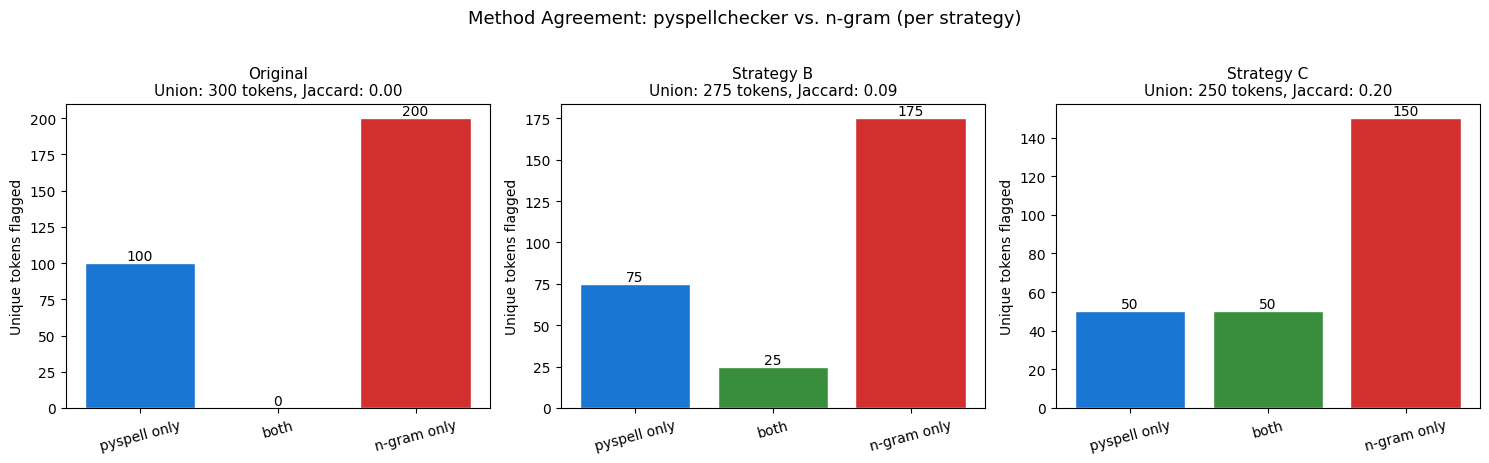

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, (_, row) in zip(axes, agreement_df.iterrows()):
    strategy = row["strategy"]
    categories = ["pyspell only", "both", "n-gram only"]
    counts     = [row["n_pyspell_only"], row["n_both"], row["n_ngram_only"]]
    colors     = ["#1976d2", "#388e3c", "#d32f2f"]

    bars = ax.bar(categories, counts, color=colors, edgecolor="white")
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f"{count:,}", ha="center", fontsize=10)

    total = row["n_union"]
    jaccard = row["jaccard"]
    ax.set_title(f"{STRATEGY_DISPLAY[strategy]}\nUnion: {total:,} tokens, Jaccard: {jaccard:.2f}",
                 fontsize=11)
    ax.set_ylabel("Unique tokens flagged")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Method Agreement: pyspellchecker vs. n-gram (per strategy)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_method_agreement.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2 Example tokens per agreement category

In [19]:
# For each strategy, save sample tokens from each agreement category
example_rows = []
for strategy in STRATEGIES:
    py_set = flag_sets[(strategy, "pyspell")]
    ng_set = flag_sets[(strategy, "ngram")]

    both    = sorted(py_set & ng_set)[:15]
    only_py = sorted(py_set - ng_set)[:15]
    only_ng = sorted(ng_set - py_set)[:15]

    for token in both:
        example_rows.append({"strategy": strategy, "category": "both", "token": token})
    for token in only_py:
        example_rows.append({"strategy": strategy, "category": "pyspell_only", "token": token})
    for token in only_ng:
        example_rows.append({"strategy": strategy, "category": "ngram_only", "token": token})

examples_df = pd.DataFrame(example_rows)
examples_df.to_csv(DST_DIR / "_examples_method_agreement.csv", index=False)
print(f"Saved {len(examples_df)} example rows for qualitative inspection")
print(f"\n=== Sample: tokens flagged by BOTH methods (Strategy C) ===")
print(examples_df[(examples_df["strategy"] == "strategy_C")
                  & (examples_df["category"] == "both")].head(10).to_string(index=False))

Saved 120 example rows for qualitative inspection

=== Sample: tokens flagged by BOTH methods (Strategy C) ===
  strategy category  token
strategy_C     both   aluo
strategy_C     both  anako
strategy_C     both     bh
strategy_C     both boyito
strategy_C     both   buet
strategy_C     both   daaj
strategy_C     both   ente
strategy_C     both erbage
strategy_C     both    etu
strategy_C     both   geus


## 5. Comparison 2 — Strategy effect, per method

For each method, how does the choice of vocabulary strategy affect:
- Per-dict flag rate
- Which specific tokens get flagged

Two outputs: a per-dict scatter showing flag rate movement across strategies,
and a "tokens that moved" table showing concrete examples of tokens whose
classification changed between strategies.

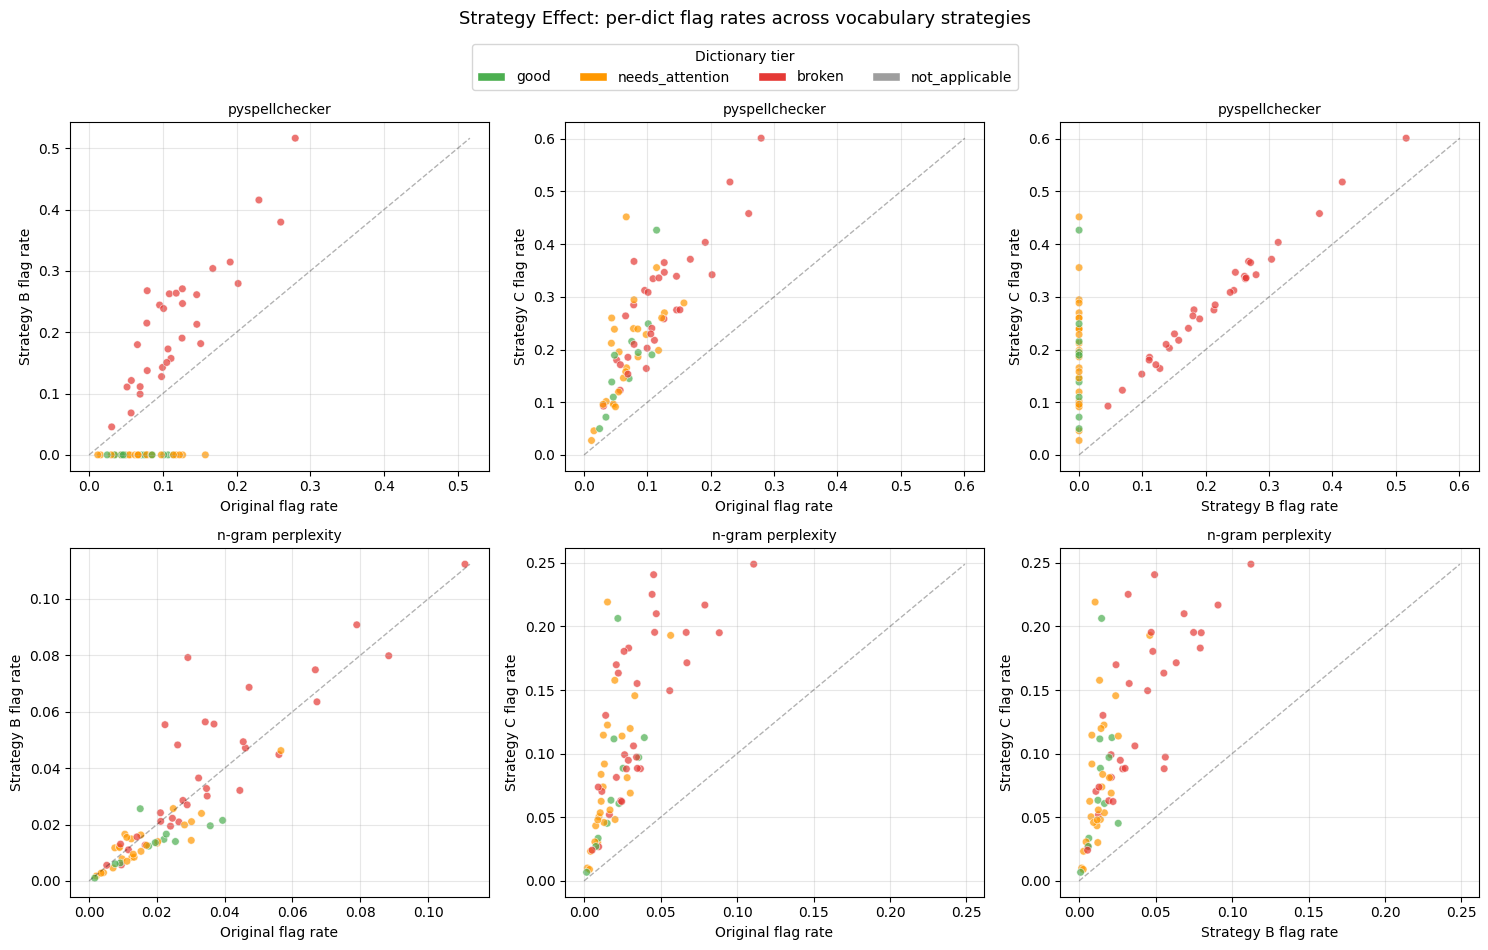

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row_idx, method in enumerate(METHODS):
    method_data = aggregates[aggregates["method"] == method]

    # Pivot to wide: rows=dict_id, cols=strategy, values=flag_rate
    pivot = method_data.pivot_table(
        index="dict_id", columns="strategy", values="flag_rate", aggfunc="first"
    )
    # Tier per dict for coloring
    pivot["tier"] = pivot.index.map(tier_map)

    tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800",
                   "broken": "#e53935", "not_applicable": "#9e9e9e"}

    # Three pairwise scatters: original vs B, original vs C, B vs C
    pairs = [("original", "strategy_B"), ("original", "strategy_C"), ("strategy_B", "strategy_C")]
    for col_idx, (x_strat, y_strat) in enumerate(pairs):
        ax = axes[row_idx, col_idx]
        if x_strat not in pivot.columns or y_strat not in pivot.columns:
            ax.text(0.5, 0.5, "(data missing)", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{METHOD_DISPLAY[method]}: {x_strat} vs {y_strat}", fontsize=10)
            continue

        x_vals = pivot[x_strat]
        y_vals = pivot[y_strat]
        colors = [tier_colors.get(t, "#9e9e9e") for t in pivot["tier"]]

        ax.scatter(x_vals, y_vals, c=colors, s=30, alpha=0.7, edgecolor="white", linewidth=0.5)

        # Diagonal y=x reference
        max_val = max(x_vals.max(), y_vals.max()) if len(x_vals) > 0 else 1
        ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3, linewidth=1)

        ax.set_xlabel(f"{STRATEGY_DISPLAY[x_strat]} flag rate")
        ax.set_ylabel(f"{STRATEGY_DISPLAY[y_strat]} flag rate")
        ax.set_title(f"{METHOD_DISPLAY[method]}", fontsize=10)
        ax.grid(alpha=0.3)

# Legend (just once, on the figure)
legend_elements = [Patch(facecolor=c, edgecolor="white", label=t)
                   for t, c in {"good": "#4caf50", "needs_attention": "#ff9800",
                                "broken": "#e53935", "not_applicable": "#9e9e9e"}.items()]
fig.legend(handles=legend_elements, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02),
           fontsize=10, title="Dictionary tier")

plt.suptitle("Strategy Effect: per-dict flag rates across vocabulary strategies",
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(DST_DIR / "_strategy_effect.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.1 Strategy effect summary table

In [21]:
strategy_effect_rows = []
for method in METHODS:
    method_data = aggregates[aggregates["method"] == method]
    for strategy in STRATEGIES:
        s_data = method_data[method_data["strategy"] == strategy]
        if s_data.empty:
            continue
        strategy_effect_rows.append({
            "method":          method,
            "strategy":        strategy,
            "n_dicts":         len(s_data),
            "mean_flag_rate":  round(s_data["flag_rate"].mean(), 4),
            "median_flag_rate": round(s_data["flag_rate"].median(), 4),
            "p95_flag_rate":   round(s_data["flag_rate"].quantile(0.95), 4),
            "total_tokens":    int(s_data["total_tokens"].sum()),
            "total_flagged":   int(s_data["flagged_count"].sum()),
        })
strategy_effect_df = pd.DataFrame(strategy_effect_rows)
strategy_effect_df.to_csv(DST_DIR / "_strategy_effect_per_method.csv", index=False)
print("=== Strategy Effect Per Method ===")
print(strategy_effect_df.to_string(index=False))

=== Strategy Effect Per Method ===
 method   strategy  n_dicts  mean_flag_rate  median_flag_rate  p95_flag_rate  total_tokens  total_flagged
pyspell   original       68          0.0925            0.0788         0.1983       1434567         119665
pyspell strategy_B       68          0.0984            0.0000         0.3107       1434567         102017
pyspell strategy_C       68          0.2348            0.2230         0.4430       1434567         336746
  ngram   original       68          0.0263            0.0216         0.0671       1434567          34106
  ngram strategy_B       68          0.0263            0.0166         0.0777       1434567          35485
  ngram strategy_C       68          0.1044            0.0885         0.2184       1434567         151258


### 5.2 Tokens that moved between strategies

In [22]:
# For each method, find tokens flagged in one strategy but not another
movement_rows = []
for method in METHODS:
    s_orig = flag_sets.get((STRATEGIES[0], method), set())
    s_b    = flag_sets.get(("strategy_B", method), set())
    s_c    = flag_sets.get(("strategy_C", method), set())

    # Tokens that get flagged as we tighten the vocab (more tokens flagged in C than B)
    new_in_c     = sorted(s_c - s_b)[:15]
    new_in_b     = sorted(s_b - s_orig)[:15]
    flagged_only_in_orig = sorted(s_orig - s_b - s_c)[:15]

    for token in new_in_c:
        movement_rows.append({
            "method": method,
            "movement": "newly_flagged_in_C_vs_B",
            "token": token,
            "interpretation": "Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches",
        })
    for token in new_in_b:
        movement_rows.append({
            "method": method,
            "movement": "newly_flagged_in_B_vs_original",
            "token": token,
            "interpretation": "Token in original vocab (admitted noise) but excluded from B — likely a noise word B correctly rejects",
        })
    for token in flagged_only_in_orig:
        movement_rows.append({
            "method": method,
            "movement": "flagged_only_in_original",
            "token": token,
            "interpretation": "Token original method missed but B/C didn't catch — possibly a coverage anomaly in original",
        })

movement_df = pd.DataFrame(movement_rows)
movement_df.to_csv(DST_DIR / "_examples_strategy_movement.csv", index=False)
print(f"Saved {len(movement_df)} movement examples")
print(f"\n=== Sample: tokens newly flagged in C vs B (pyspell method) ===")
print(movement_df[(movement_df["method"] == "pyspell")
                  & (movement_df["movement"] == "newly_flagged_in_C_vs_B")].head(10)[
    ["token", "interpretation"]
].to_string(index=False))

Saved 90 movement examples

=== Sample: tokens newly flagged in C vs B (pyspell method) ===
   token                                                                                       interpretation
    aluo Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
   anako Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
      bh Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
    bibo Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
bilangen Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
    bolo Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
   bongo Token appears in B's vocab but not C's — a real word C considers too rare, OR a true error C catches
    buet Token appears in B'

## 6. Comparison 3 — Tier alignment, per method × strategy

For each method × strategy combination, does per-dict flag rate correlate
with the dict's structural tier from sanity check v2? If methods are
measuring real quality, broken-tier dicts should have higher flag rates
than good-tier dicts.

Two outputs: box plots grouped by tier (visualization), and Spearman ρ
correlations (single-number summary suitable for thesis tables).

C:\Users\Legion\AppData\Local\Temp\ipykernel_11168\2864130425.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_11168\2864130425.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_11168\2864130425.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
C:\Users\Legion\AppData\Local\Temp\ipykernel_1

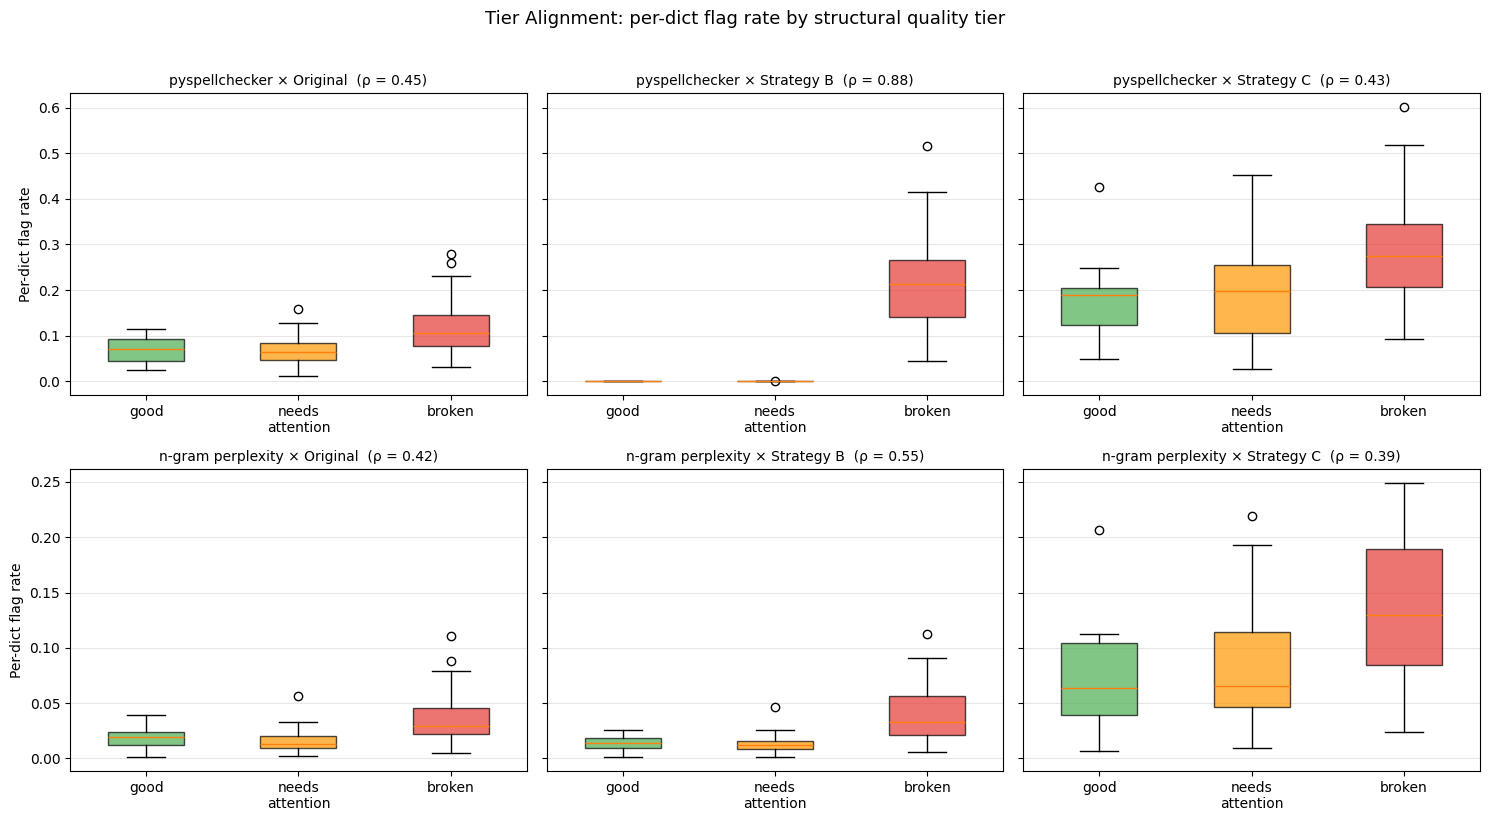


=== Tier-Flag Rate Correlations (Spearman) ===
 method   strategy  spearman_rho  p_value  n
pyspell   original         0.451   0.0001 68
pyspell strategy_B         0.882   0.0000 68
pyspell strategy_C         0.427   0.0003 68
  ngram   original         0.425   0.0003 68
  ngram strategy_B         0.555   0.0000 68
  ngram strategy_C         0.389   0.0010 68


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")

tier_order = ["good", "needs_attention", "broken"]  # exclude not_applicable for box plots
tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800", "broken": "#e53935"}

correlation_rows = []
for row_idx, method in enumerate(METHODS):
    for col_idx, strategy in enumerate(STRATEGIES):
        ax = axes[row_idx, col_idx]
        cell_data = aggregates[
            (aggregates["method"] == method)
            & (aggregates["strategy"] == strategy)
            & (aggregates["tier"].isin(tier_order))
        ]
        if cell_data.empty:
            ax.text(0.5, 0.5, "(no data)", ha="center", va="center", transform=ax.transAxes)
            continue

        # Box plot per tier
        plot_data = [cell_data[cell_data["tier"] == t]["flag_rate"].values for t in tier_order]
        bp = ax.boxplot(plot_data, labels=[t.replace("_", "\n") for t in tier_order],
                        patch_artist=True, widths=0.5)
        for patch, t in zip(bp["boxes"], tier_order):
            patch.set_facecolor(tier_colors[t])
            patch.set_alpha(0.7)

        # Compute Spearman ρ between flag_rate and tier_rank
        tier_rank = {"good": 0, "needs_attention": 1, "broken": 2}
        cell_data = cell_data.copy()
        cell_data["tier_rank"] = cell_data["tier"].map(tier_rank)
        if cell_data["tier_rank"].nunique() > 1:
            from scipy.stats import spearmanr
            rho, p_value = spearmanr(cell_data["tier_rank"], cell_data["flag_rate"])
        else:
            rho, p_value = float("nan"), float("nan")

        correlation_rows.append({
            "method": method,
            "strategy": strategy,
            "spearman_rho": round(float(rho), 3) if not np.isnan(rho) else None,
            "p_value": round(float(p_value), 4) if not np.isnan(p_value) else None,
            "n": len(cell_data),
        })

        rho_text = f"ρ = {rho:.2f}" if not np.isnan(rho) else "ρ = NA"
        ax.set_title(f"{METHOD_DISPLAY[method]} × {STRATEGY_DISPLAY[strategy]}  ({rho_text})",
                     fontsize=10)
        ax.set_ylabel("Per-dict flag rate" if col_idx == 0 else "")
        ax.grid(alpha=0.3, axis="y")

correlation_df = pd.DataFrame(correlation_rows)
correlation_df.to_csv(DST_DIR / "_tier_alignment_per_pair.csv", index=False)

plt.suptitle("Tier Alignment: per-dict flag rate by structural quality tier",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_tier_alignment.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n=== Tier-Flag Rate Correlations (Spearman) ===")
print(correlation_df.to_string(index=False))

## 7. Patterns analysis (separate, not comparable to flagging)

The pattern miner doesn't flag tokens itself — it analyzes the n-gram method's
flagged tokens and finds character-pattern itemsets that recur. So instead of
treating it as a comparable method, we present its findings directly: which
systematic OCR error patterns explain the most n-gram flags.

In [24]:
patterns_summary_rows = []

for strategy in STRATEGIES:
    patterns_path = NGRAM_ROOT / strategy / "_top_systematic_patterns.csv"
    if not patterns_path.exists():
        print(f"  ⚠ Patterns missing for {strategy}: {patterns_path}")
        continue

    df = pd.read_csv(patterns_path)
    # Top 10 multi-element patterns per strategy
    top_n = df.head(10)
    for _, row in top_n.iterrows():
        patterns_summary_rows.append({
            "strategy":      strategy,
            "pattern":       row["pattern"],
            "support":       row["support"],
            "itemset_size":  row["itemset_size"],
            "examples":      row["examples"],
        })

patterns_summary_df = pd.DataFrame(patterns_summary_rows)
patterns_summary_df.to_csv(DST_DIR / "_systematic_patterns_summary.csv", index=False)

print(f"Loaded {len(patterns_summary_df)} top patterns across all strategies")
print(f"\n=== Top 5 patterns per strategy ===")
for strategy in STRATEGIES:
    s_data = patterns_summary_df[patterns_summary_df["strategy"] == strategy]
    if s_data.empty:
        continue
    print(f"\n--- {STRATEGY_DISPLAY[strategy]} ---")
    for _, row in s_data.head(5).iterrows():
        print(f"  {row['pattern']:<45} support={row['support']:.3f}")
        print(f"      examples: {row['examples'][:80]}")

Loaded 30 top patterns across all strategies

=== Top 5 patterns per strategy ===

--- Original ---
  2g:^r + 3g:^^r                                support=0.080
      examples: rp; rt; rl; republik; rh; rg; rllmah; rm
  2g:^n + 3g:^^n                                support=0.080
      examples: nm; nt; nj; nl; nd; niirip; ntb; nn
  2g:p$ + 3g:p$$                                support=0.070
      examples: rp; bioskop; mp; smp; niirip; ep; sp; tp
  2g:^m + 3g:^^m                                support=0.070
      examples: muhammad; mk; mb; mp; mrk; magrib; mm; mt
  2g:^l + 3g:^^l                                support=0.070
      examples: lmpor; ln; lj; lg; lf; laaigo; lse; lw

--- Strategy B ---
  2g:e$ + 3g:e$$                                support=0.120
      examples: nyoe; ice; uge; droe; uroe; ape; oge; ume
  2g:o$ + 3g:o$$                                support=0.100
      examples: ltuyuo; boyito; yio; qo; woluwo; kaghno; eo; yiqo
  2g:^k + 3g:^^k                           

### 7.1 Pattern visualization

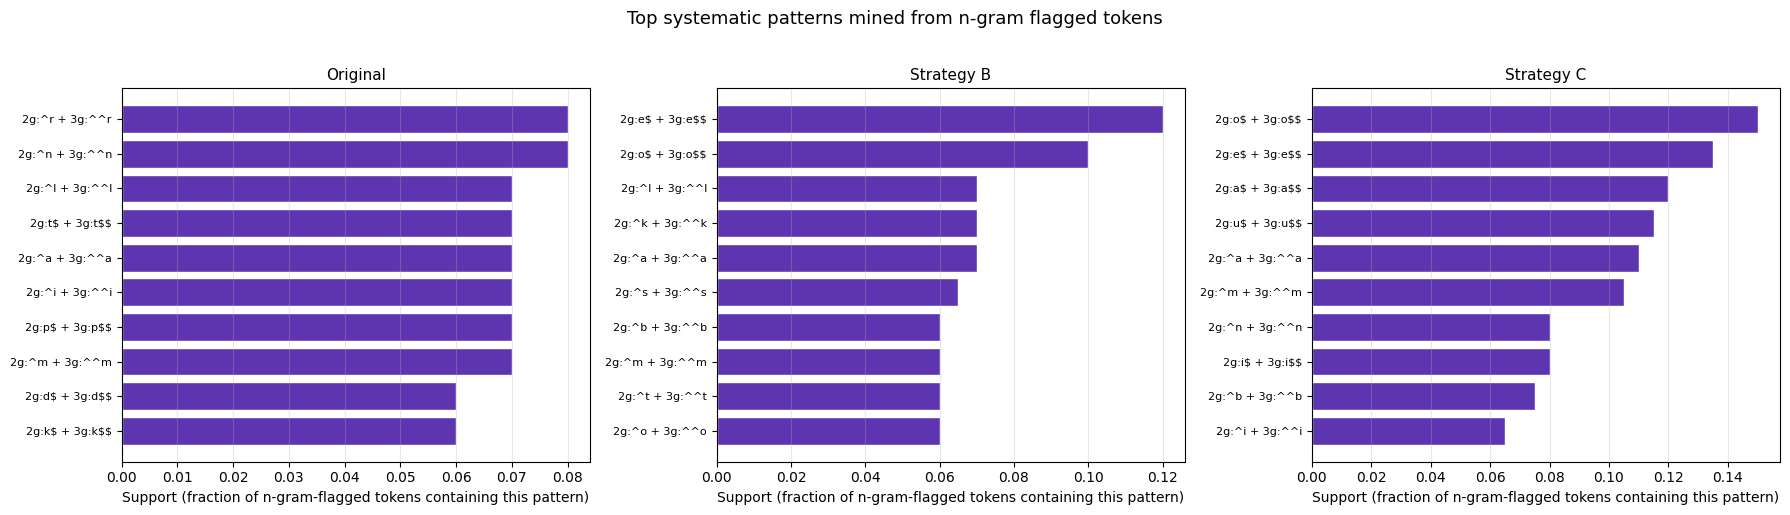

In [25]:
# Bar chart of top patterns per strategy, with support values
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, strategy in zip(axes, STRATEGIES):
    s_data = patterns_summary_df[patterns_summary_df["strategy"] == strategy]
    if s_data.empty:
        ax.text(0.5, 0.5, f"(no patterns for {strategy})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(STRATEGY_DISPLAY[strategy])
        continue

    s_data = s_data.sort_values("support", ascending=True).tail(10)
    ax.barh(range(len(s_data)), s_data["support"].values, color="#5e35b1", edgecolor="white")
    ax.set_yticks(range(len(s_data)))
    ax.set_yticklabels(s_data["pattern"].values, fontsize=8)
    ax.set_xlabel("Support (fraction of n-gram-flagged tokens containing this pattern)")
    ax.set_title(STRATEGY_DISPLAY[strategy], fontsize=11)
    ax.grid(alpha=0.3, axis="x")

plt.suptitle("Top systematic patterns mined from n-gram flagged tokens",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_systematic_patterns.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Headline summary table

A compact summary suitable for the thesis abstract / first table. One row
per method × strategy combination with the headline numbers.

In [26]:
# Build summary: for each method × strategy, the key numbers
summary_rows = []
for method, strategy in product(METHODS, STRATEGIES):
    method_data = aggregates[(aggregates["method"] == method) & (aggregates["strategy"] == strategy)]
    if method_data.empty:
        continue

    # Flag set
    flag_set = flag_sets.get((strategy, method), set())

    # Tier correlation
    corr_row = correlation_df[(correlation_df["method"] == method)
                               & (correlation_df["strategy"] == strategy)]
    rho = corr_row["spearman_rho"].iloc[0] if len(corr_row) > 0 else None

    summary_rows.append({
        "method":             METHOD_DISPLAY[method],
        "strategy":           STRATEGY_DISPLAY[strategy],
        "n_dicts_processed":  len(method_data),
        "total_tokens":       int(method_data["total_tokens"].sum()),
        "total_flagged":      int(method_data["flagged_count"].sum()),
        "unique_flagged":     len(flag_set),
        "mean_flag_rate":     round(method_data["flag_rate"].mean(), 4),
        "tier_correlation":   rho,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(DST_DIR / "_headline_summary.csv", index=False)
print("=== Headline Summary ===")
print(summary_df.to_string(index=False))
print(f"\nAll comparison outputs in: {DST_DIR.resolve()}")

=== Headline Summary ===
           method   strategy  n_dicts_processed  total_tokens  total_flagged  unique_flagged  mean_flag_rate  tier_correlation
   pyspellchecker   Original                 68       1434567         119665             100          0.0925             0.451
   pyspellchecker Strategy B                 68       1434567         102017             100          0.0984             0.882
   pyspellchecker Strategy C                 68       1434567         336746             100          0.2348             0.427
n-gram perplexity   Original                 68       1434567          34106             200          0.0263             0.425
n-gram perplexity Strategy B                 68       1434567          35485             200          0.0263             0.555
n-gram perplexity Strategy C                 68       1434567         151258             200          0.1044             0.389

All comparison outputs in: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data

## 9. Reading guide

**The three figures are the meat of this analysis:**

- `_method_agreement.png` answers: do pyspell and n-gram catch the same
  errors? Look at Jaccard scores. Low Jaccard = methods are complementary
  (good for a multi-method evaluation argument). High Jaccard = methods are
  redundant (one is sufficient).

- `_strategy_effect.png` answers: does tighter vocabulary filtering produce
  different per-dict flag rates? The y=x diagonal shows "no change."
  Points above the diagonal mean the y-axis strategy flags more than x.
  If many points move from below-diagonal to above as strategies tighten,
  filtering is producing real signal change.

- `_tier_alignment.png` answers: does each method × strategy agree with the
  independent structural quality measurement? Higher Spearman ρ = better
  alignment. ρ near 0 = method is measuring something different from
  structural rules.

**The three CSV outputs supplement each figure:**

- `_method_agreement_per_strategy.csv` — exact union/intersection counts
- `_strategy_effect_per_method.csv` — flag rate distributions
- `_tier_alignment_per_pair.csv` — Spearman ρ values with p-values

**The three example CSVs let you inspect concrete tokens:**

- `_examples_method_agreement.csv` — what tokens fall in each agreement
  category? Use this to argue methods are catching different error types.
- `_examples_strategy_movement.csv` — what tokens moved as strategy
  tightened? Spot-check whether moves are "real errors caught by tighter
  vocab" or "real words now incorrectly flagged."
- `_systematic_patterns_summary.csv` — what character patterns explain the
  n-gram flags? Use this for the patterns analysis section your advisor
  asked for.

**What this analysis cannot tell you (yet):**

Without gold annotation, all comparisons here are method-vs-method or
method-vs-structural. We can say method A and B agree on X% of tokens, or
method A correlates with structural tier at ρ=0.5, but we cannot say method
A has 90% precision. That comes from the gold annotation work in §SQ4.